## F1 Project Starter

core           INFO 	Loading data for British Grand Prix - Race [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No ca

First 5 rows of lap data:
  Driver  LapNumber                LapTime Compound  Stint  LapTimeSeconds
0    VER        1.0 0 days 00:01:37.167000   MEDIUM    1.0          97.167
1    VER        2.0 0 days 00:01:33.433000   MEDIUM    1.0          93.433
2    VER        3.0 0 days 00:01:32.730000   MEDIUM    1.0          92.730
3    VER        4.0 0 days 00:01:32.780000   MEDIUM    1.0          92.780
4    VER        5.0 0 days 00:01:32.582000   MEDIUM    1.0          92.582


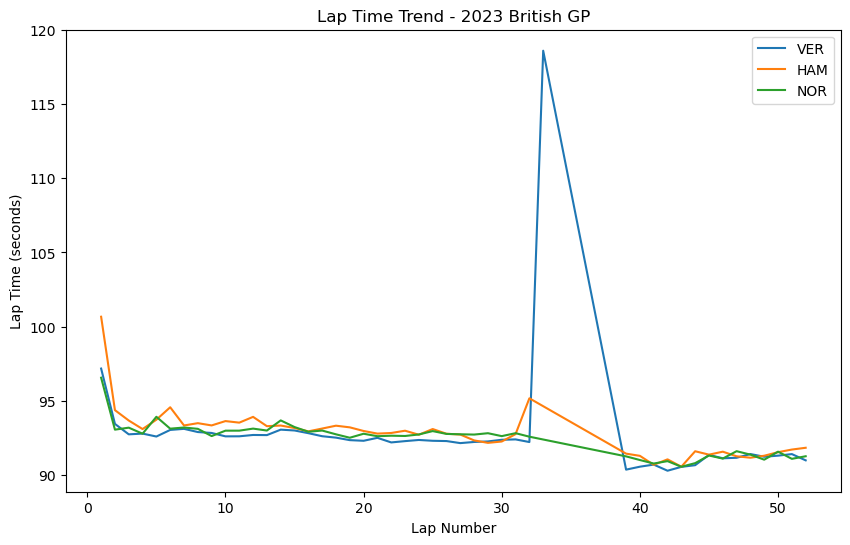

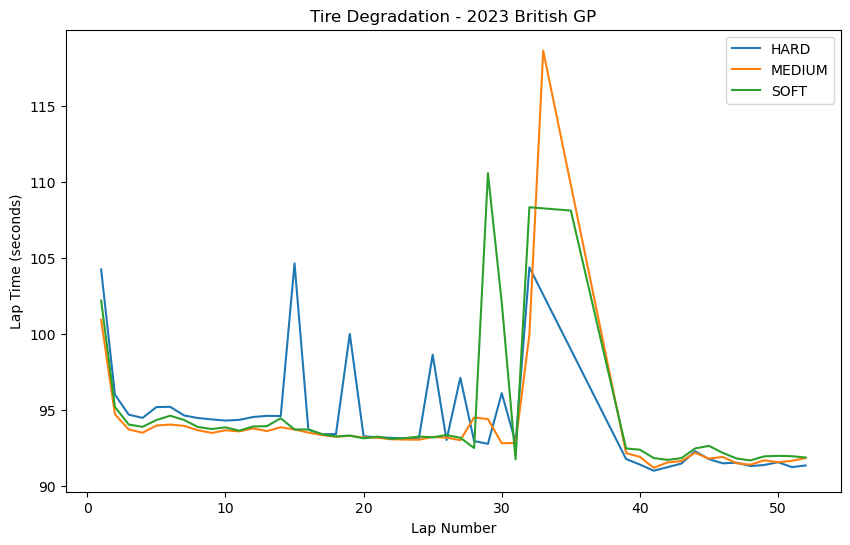

In [4]:
# ----------------------------
# Day 1: F1 Project Starter
# ----------------------------

# Step 0: Install packages (only the first time)
# pip install fastf1 pandas matplotlib

# ----------------------------
# Step 1: Import packages + create cache
# ----------------------------
import fastf1
import pandas as pd
import matplotlib.pyplot as plt
import os

# Automatically create cache folder
if not os.path.exists('cache'):
    os.makedirs('cache')

# Enable FastF1 cache (downloaded data will be stored here)
fastf1.Cache.enable_cache('cache')

# ----------------------------
# Step 2: Load race session
# ----------------------------
# 2023 British GP, Silverstone
session = fastf1.get_session(2023, 'British Grand Prix', 'R')  # 'R' = Race
session.load()  # First time will download data automatically

# ----------------------------
# Step 3: Extract lap data
# ----------------------------
laps = session.laps

# Select important columns
df = laps[['Driver', 'LapNumber', 'LapTime', 'Compound', 'Stint']].copy()

# Convert lap time to seconds for easier analysis
df['LapTimeSeconds'] = df['LapTime'].dt.total_seconds()

# Filter out pit laps, crashes, and other anomalies
df = df[df['LapTimeSeconds'] < 120]

print("First 5 rows of lap data:")
print(df.head())

# ----------------------------
# Step 4: Lap Time Trend (Analysis 1)
# ----------------------------
drivers = ['VER', 'HAM', 'NOR']  # You can change drivers as needed
plt.figure(figsize=(10,6))

for d in drivers:
    driver_df = df[df['Driver'] == d]
    plt.plot(driver_df['LapNumber'], driver_df['LapTimeSeconds'], label=d)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Lap Time Trend - 2023 British GP')
plt.legend()
plt.show()

# ----------------------------
# Step 5: Tire Degradation (Analysis 2)
# ----------------------------
plt.figure(figsize=(10,6))

# Compute average lap time per tire compound per lap
tire_avg = df.groupby(['Compound', 'LapNumber'])['LapTimeSeconds'].mean().reset_index()

# Plot tire degradation curves
for compound in tire_avg['Compound'].unique():
    sub = tire_avg[tire_avg['Compound'] == compound]
    plt.plot(sub['LapNumber'], sub['LapTimeSeconds'], label=compound)

plt.xlabel('Lap Number')
plt.ylabel('Lap Time (seconds)')
plt.title('Tire Degradation - 2023 British GP')
plt.legend()
plt.show()

## F1 Project Plan
### Pit Stop & Stint Analysis

Goal: Analyze pit stop timing and stint performance to understand race strategy.

#### 1. Check Stints for Each Driver

In [5]:
# Count laps per stint to see pit stop timing
stint_summary = df.groupby(['Driver', 'Stint'])['LapNumber'].min().reset_index()
print(stint_summary)

   Driver  Stint  LapNumber
0     ALB    1.0        1.0
1     ALB    2.0       39.0
2     ALO    1.0        1.0
3     ALO    2.0       39.0
4     BOT    1.0        1.0
5     BOT    2.0       39.0
6     DEV    1.0        1.0
7     DEV    2.0       28.0
8     DEV    3.0       35.0
9     GAS    1.0        1.0
10    GAS    2.0       39.0
11    HAM    1.0        1.0
12    HAM    2.0       39.0
13    HUL    1.0        1.0
14    HUL    2.0        9.0
15    HUL    3.0       35.0
16    LEC    1.0        1.0
17    LEC    2.0       19.0
18    LEC    3.0       39.0
19    MAG    1.0        1.0
20    NOR    1.0        1.0
21    NOR    2.0       39.0
22    OCO    1.0        1.0
23    PER    1.0        1.0
24    PER    2.0       29.0
25    PIA    1.0        1.0
26    PIA    2.0       30.0
27    RUS    1.0        1.0
28    RUS    2.0       29.0
29    SAI    1.0        1.0
30    SAI    2.0       27.0
31    SAR    1.0        1.0
32    SAR    2.0       30.0
33    STR    1.0        1.0
34    STR    2.0    

Insight: First lap of each stint indicates pit stop timing.
Can calculate laps between pit stops to see stint length.

#### 2. Pit Stop vs Lap Time

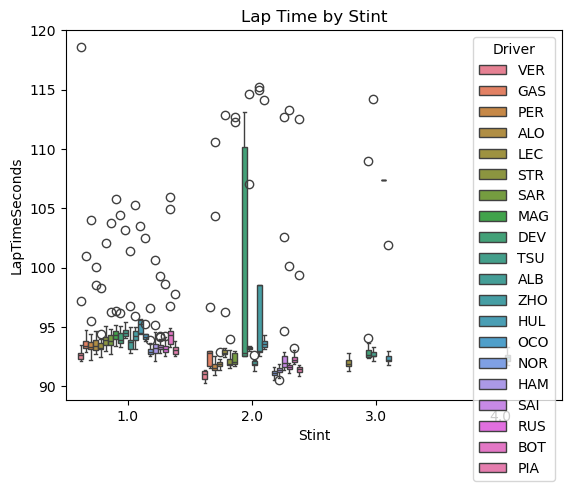

In [6]:
import seaborn as sns

# Compare lap time before and after pit stops
sns.boxplot(x='Stint', y='LapTimeSeconds', hue='Driver', data=df)
plt.title('Lap Time by Stint')
plt.show()

Insight: Shows performance gain or loss after pit stops.
To link pit timing to strategy outcomes.

### Simple Regression Model + Tableau Dashboard

#### 1. Regression Model (Predict Lap Time)

In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# Encode tire compound
encoder = OneHotEncoder()
tire_encoded = encoder.fit_transform(df[['Compound']]).toarray()

# Features: Tire type + lap number
X = np.column_stack([df['LapNumber'], tire_encoded])
y = df['LapTimeSeconds']

# Fit linear regression
model = LinearRegression()
model.fit(X, y)

# Predict lap time (example)
y_pred = model.predict(X)
print("First 5 predictions:", y_pred[:5])

First 5 predictions: [95.00621    94.93573395 94.8652579  94.79478186 94.72430581]


Insight:
Quantify tire impact on lap time.
Built a simple regression model to estimate lap time based on tire compound and lap number.

In [8]:
df.to_csv('f1_lap_data.csv', index=False)

In [9]:
stint_summary.to_csv('f1_stint_data.csv', index=False)